# Sistemas Inteligentes - 2026.1
## Projeto 03 - K-NN
Autores: Lavínia Dantas e Jefferson Bezerra


## Contexto

Este projeto tem como objetivo construir um modelo de classificação utilizando o algoritmo k-Nearest Neighbors (k-NN) para prever a qualidade de vinhos tintos, categorizando-os em três classes: ruim, médio e bom. Para isso, é utilizado o dataset Wine Quality, especificamente o arquivo voltado para vinhos tintos da região do Vinho Verde, em Portugal.

O conjunto de dados reúne 1.599 amostras e contém 11 atributos físico-químicos, como pH, teor alcoólico e acidez, que servem como base para a predição do rótulo de qualidade atribuído originalmente por especialistas. A iniciativa busca automatizar um processo historicamente subjetivo e lento, oferecendo aplicações práticas na precificação, certificação e controle de qualidade na indústria vinícola.

UCI Wine Quality: https://archive.ics.uci.edu/ml/datasets/Wine+Quality


## Preparação do Ambiente de Trabalho

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

####Obtenção dos dados pelo repositório UCI

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

## 1 - Carregamento do dataset e recodificação da variavel (quality) em três classes: notas ≤ 5 como ruim, 6-7 como médio e ≥ 8 como bom e normalização de todos os atributos utilizando o Z-Score.  

In [ ]:
# Recodificação da variável 'quality'
def recodificar_qualidade(nota):
    if nota <= 5:
        return 'ruim'
    elif nota <= 7:
        return 'médio'
    else:
        return 'bom'

df['classe_qualidade'] = df['quality'].apply(recodificar_qualidade)

# Separação de features (X) e target (y)
X = df.drop(['quality', 'classe_qualidade'], axis=1)
y = df['classe_qualidade']

# Normalização utilizando (Z-score)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

A normalização é essencial no algoritmo K-NN, pois ele utiliza medidas de distância para determinar os vizinhos mais próximos. Como as variáveis possuem escalas diferentes, atributos com valores maiores poderiam dominar o cálculo da distância, prejudicando o desempenho do modelo.

## 2 - Divisão treino/teste: dividindo os dados em 80% para treino e 20% para teste, utilizando divisão estratificada para garantir que a proporcão das três classes seja mantida em ambos os conjuntos.

In [ ]:
# Divisão de 80% para treino e 20% para teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.20, random_state=42, stratify=y
)

## 3 - Treinamento e escolha do 𝑘: treinamento do modelo para diferentes valores de 𝑘 (ex: 1, 3, 5, 7, 11) utilizando validação cruzada de 5 folds sobre o conjunto de treino e plotando a acurácia média em função de 𝑘 e escolha do valor com melhor desempenho.

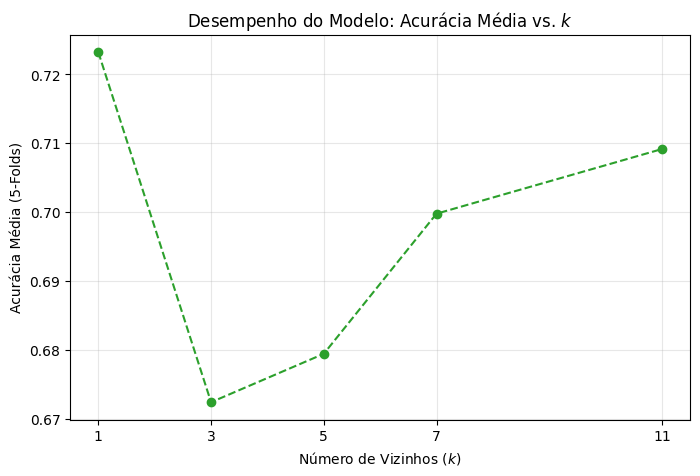

Valor de k selecionado: 1


In [ ]:
valores_k = [1, 3, 5, 7, 11]
resultados_cv = []

# Treinamento e Validação Cruzada (5 folds)
for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    resultados_cv.append(scores.mean())

# Plotagem da Acurácia Média
plt.figure(figsize=(8, 5))
plt.plot(valores_k, resultados_cv, marker='o', color='#2ca02c', linestyle='--')
plt.title('Desempenho do Modelo: Acurácia Média vs. $k$')
plt.xlabel('Número de Vizinhos ($k$)')
plt.ylabel('Acurácia Média (5-Folds)')
plt.xticks(valores_k)
plt.grid(True, alpha=0.3)
plt.show()

# Seleção automática do melhor k
melhor_k = valores_k[np.argmax(resultados_cv)]
print(f"Valor de k selecionado: {melhor_k}")

A análise dos resultados demonstra que valores baixos de K tendem a gerar maior acurácia, porém tornam o modelo mais sensível a ruídos, podendo levar ao overfitting, onde o modelo memoriza os dados de treino.

Por outro lado, valores mais altos de K tornam o modelo mais generalista, reduzindo a variabilidade, mas podendo levar ao underfitting, onde o modelo deixa de capturar padrões importantes nos dados.

Dessa forma, a escolha de K representa um equilíbrio entre viés e variância, sendo necessário selecionar um valor que maximize o desempenho sem comprometer a capacidade de generalização.

## 4 - Avaliação do modelo: utilização do conjunto de teste e calculando a matriz de confusão e as métricas de acurácia, precisão, recall e F1-score para cada classe.

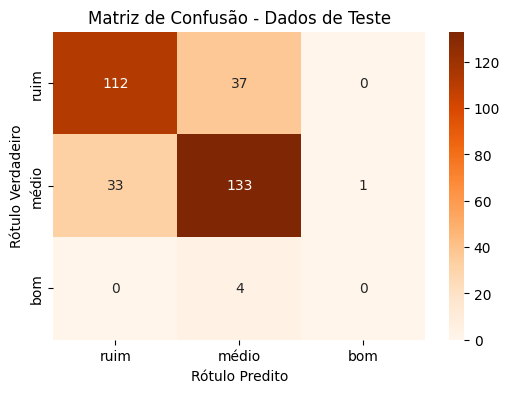

Relatório de Classificação:

              precision    recall  f1-score   support

        ruim       0.77      0.75      0.76       149
       médio       0.76      0.80      0.78       167
         bom       0.00      0.00      0.00         4

    accuracy                           0.77       320
   macro avg       0.51      0.52      0.51       320
weighted avg       0.76      0.77      0.76       320



In [ ]:
# Instanciar e treinar o modelo final
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_train, y_train)

# Predições no conjunto de teste
y_pred = knn_final.predict(X_test)

# Matriz de Confusão
labels = ['ruim', 'médio', 'bom']
matriz_confusao = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Predito')
plt.show()

# Métricas de Desempenho
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, labels=labels))

A análise da matriz de confusão indica que o modelo apresenta maior dificuldade em diferenciar as classes "ruim" e "médio", sendo essa a principal fonte de erro.

Observa-se também que a classe "bom" possui desempenho inferior, o que pode ser explicado pela baixa quantidade de amostras dessa categoria no conjunto de dados, caracterizando um desbalanceamento.

Esse comportamento evidencia que o modelo tende a favorecer as classes mais frequentes, apresentando menor capacidade de generalização para classes minoritárias.